# DBSCAN — University Analytics: Student Study Behaviour Clustering
**Scenario:** A university's learning analytics team has logged student activity  
on the online learning platform across a full semester.  

**Goal:** Discover natural study behaviour patterns *without* any pre-defined labels,  
and identify students with unusual patterns who may need support.

---
## Contents
1. Generate a realistic synthetic student activity dataset  
2. Explore the data  
3. Feature engineering  
4. Run DBSCAN  
5. Visualise and interpret clusters  
6. At-risk student identification  
7. Actionable recommendations  


## 1 — Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

np.random.seed(7)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
print("Setup complete.")


Setup complete.


## 2 — Generate Synthetic Student Activity Dataset

**Simulated features for each of 500 students (over one semester):**

| Feature | Description |
|---|---|
| `avg_sessions_per_week` | Average login sessions per week |
| `avg_session_length_min` | Average session duration (minutes) |
| `pct_before_exam_week` | % of total activity in the 7 days before each exam |
| `resource_variety` | Number of distinct resource types accessed (0–10) |
| `quiz_attempts_per_quiz` | Average attempts per quiz (1 = first try, 3+ = struggling) |
| `days_between_sessions` | Average days between consecutive sessions |

We simulate 4 known behaviour archetypes + genuine outliers.


In [2]:
def generate_student_data(n=500, seed=7):
    rng = np.random.default_rng(seed)

    archetypes = {
        'steady_worker':    dict(n=160, means=[4.5, 45, 0.20, 7.0, 1.3, 1.8],
                                  stds=[0.8, 10,  0.05, 1.0, 0.3, 0.5]),
        'last_min_crammer': dict(n=130, means=[1.5, 25, 0.65, 3.0, 2.2, 5.0],
                                  stds=[0.5, 8,  0.10, 1.2, 0.6, 1.2]),
        'passive_browser':  dict(n=120, means=[3.0, 12, 0.30, 2.0, 1.1, 3.0],
                                  stds=[0.7, 4,  0.07, 0.8, 0.2, 1.0]),
        'intensive_learner':dict(n=60,  means=[7.0, 80, 0.25, 9.5, 1.1, 1.0],
                                  stds=[1.0, 15, 0.06, 0.5, 0.2, 0.3]),
    }

    rows, labels = [], []
    for name, cfg in archetypes.items():
        for _ in range(cfg['n']):
            vals = [max(0.1, rng.normal(m, s)) for m, s in zip(cfg['means'], cfg['stds'])]
            vals[2] = np.clip(vals[2], 0, 1)
            rows.append(vals)
            labels.append(name)

    # Genuine outliers (30 students with unusual patterns)
    n_out = n - sum(a['n'] for a in archetypes.values())
    for _ in range(n_out):
        pattern = rng.choice(['erratic', 'ghost', 'hyper_cramming'])
        if pattern == 'erratic':
            vals = [rng.uniform(0.5, 8), rng.uniform(5, 90),
                    rng.uniform(0.1, 0.9), rng.uniform(1, 10),
                    rng.uniform(1, 4), rng.uniform(0.5, 8)]
        elif pattern == 'ghost':
            vals = [rng.uniform(0.1, 0.5), rng.uniform(2, 10),
                    rng.uniform(0.5, 0.95), rng.uniform(1, 3),
                    rng.uniform(1, 2), rng.uniform(8, 15)]
        else:
            vals = [rng.uniform(8, 15), rng.uniform(90, 180),
                    rng.uniform(0.7, 0.99), rng.uniform(5, 10),
                    rng.uniform(1, 1.5), rng.uniform(0.1, 0.5)]
        vals[2] = np.clip(vals[2], 0, 1)
        rows.append(vals)
        labels.append('outlier')

    cols = ['avg_sessions_per_week','avg_session_length_min','pct_before_exam_week',
            'resource_variety','quiz_attempts_per_quiz','days_between_sessions']
    df = pd.DataFrame(rows, columns=cols)
    df['true_archetype'] = labels
    df['student_id'] = [f'S{i+1:04d}' for i in range(len(df))]
    return df.sample(frac=1, random_state=7).reset_index(drop=True)

df = generate_student_data()
print(f"Dataset: {df.shape[0]} students, {df.shape[1]-2} features")
print(f"\nArchetype breakdown:\n{df['true_archetype'].value_counts()}")
df.head()


Dataset: 500 students, 6 features

Archetype breakdown:
true_archetype
steady_worker        160
last_min_crammer     130
passive_browser      120
intensive_learner     60
outlier               30
Name: count, dtype: int64


,avg_sessions_per_week,avg_session_length_min,pct_before_exam_week,resource_variety,quiz_attempts_per_quiz,days_between_sessions,true_archetype,student_id
0,2.240396,16.082102,0.321672,2.899161,1.102211,4.195646,passive_browser,S0309
1,4.299844,60.235294,0.178599,6.696320,1.405777,1.739615,steady_worker,S0014
2,8.122394,86.900879,0.259242,9.520868,1.204061,1.304617,intensive_learner,S0415
3,5.273158,43.592916,0.227094,7.781443,1.549355,2.260692,steady_worker,S0033
4,5.889490,78.495244,0.256946,9.172001,1.199657,0.934164,intensive_learner,S0461


## 3 — Exploratory Data Analysis

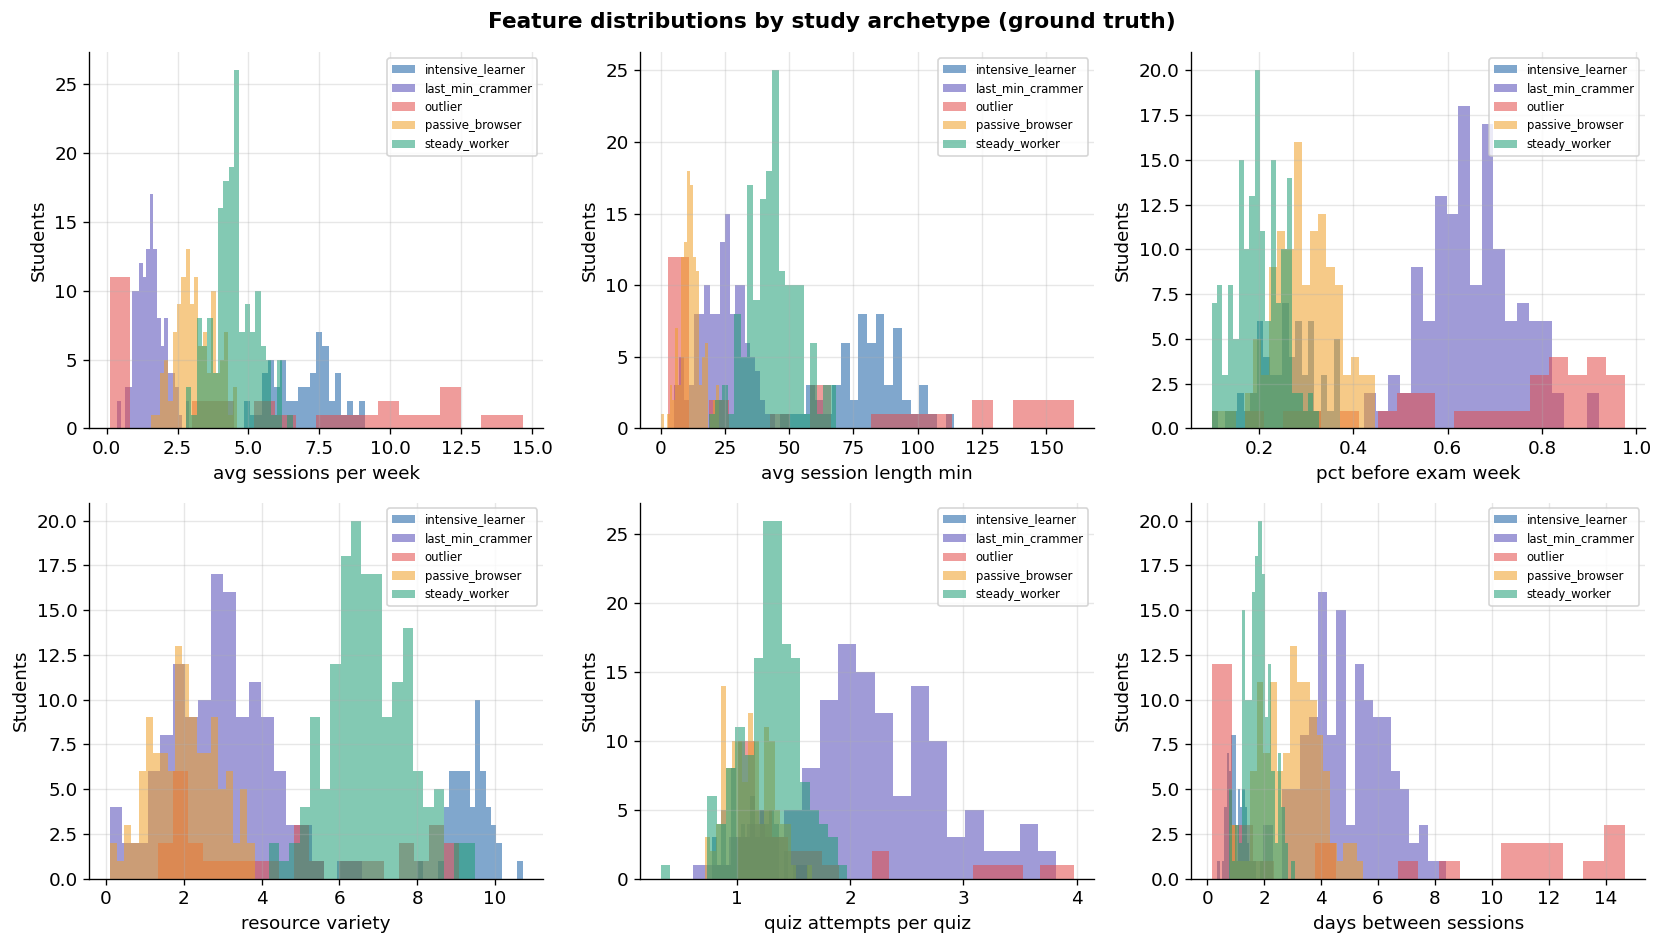

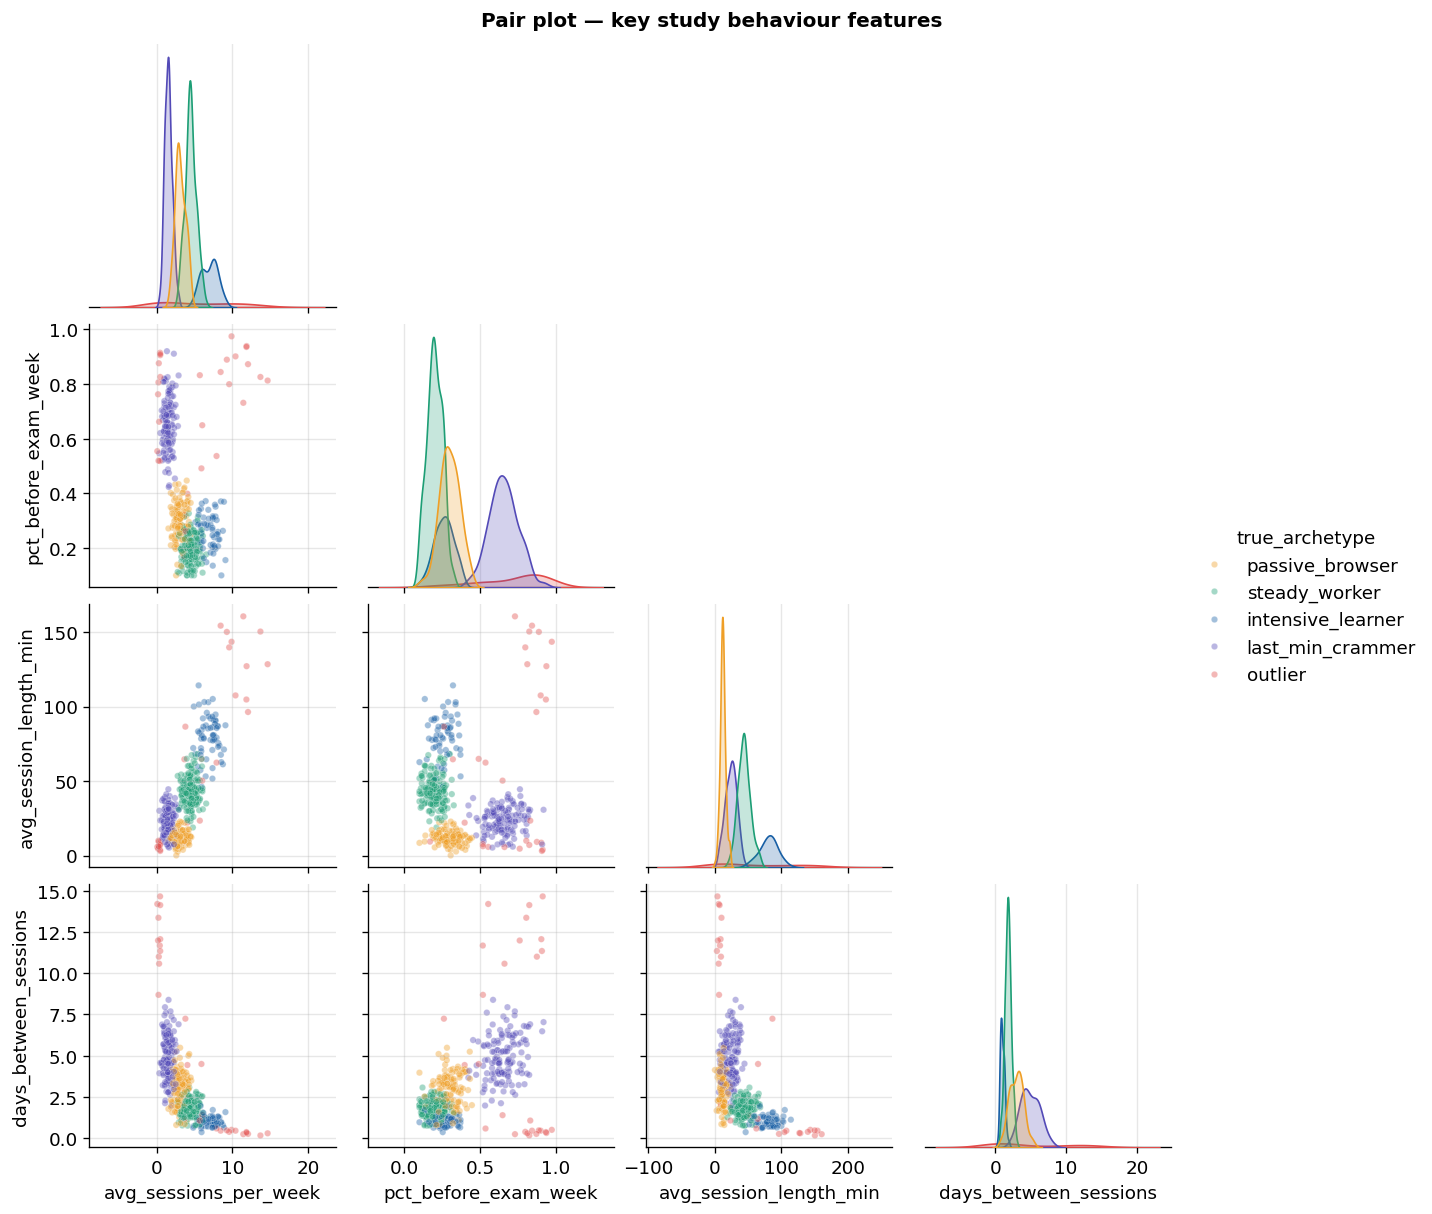

In [3]:
palette = {
    'steady_worker':    '#1D9E75',
    'last_min_crammer': '#534AB7',
    'passive_browser':  '#EF9F27',
    'intensive_learner':'#185FA5',
    'outlier':          '#E24B4A'
}

features = ['avg_sessions_per_week','avg_session_length_min','pct_before_exam_week',
            'resource_variety','quiz_attempts_per_quiz','days_between_sessions']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    ax = axes[i]
    for arch, grp in df.groupby('true_archetype'):
        ax.hist(grp[feat], bins=20, alpha=0.55, label=arch,
                color=palette[arch], edgecolor='none')
    ax.set_xlabel(feat.replace('_',' '))
    ax.set_ylabel('Students')
    ax.legend(fontsize=7)
fig.suptitle('Feature distributions by study archetype (ground truth)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot for key features
subset = df[['avg_sessions_per_week','pct_before_exam_week','avg_session_length_min',
             'days_between_sessions','true_archetype']].copy()
g = sns.pairplot(subset, hue='true_archetype', palette=palette, plot_kws={'alpha':0.4,'s':15},
                 diag_kind='kde', corner=True)
g.fig.suptitle('Pair plot — key study behaviour features', y=1.01, fontsize=12, fontweight='bold')
plt.show()


## 4 — Scale & PCA Projection

PCA variance explained: PC1=58.0%  PC2=21.2%  Total=79.2%


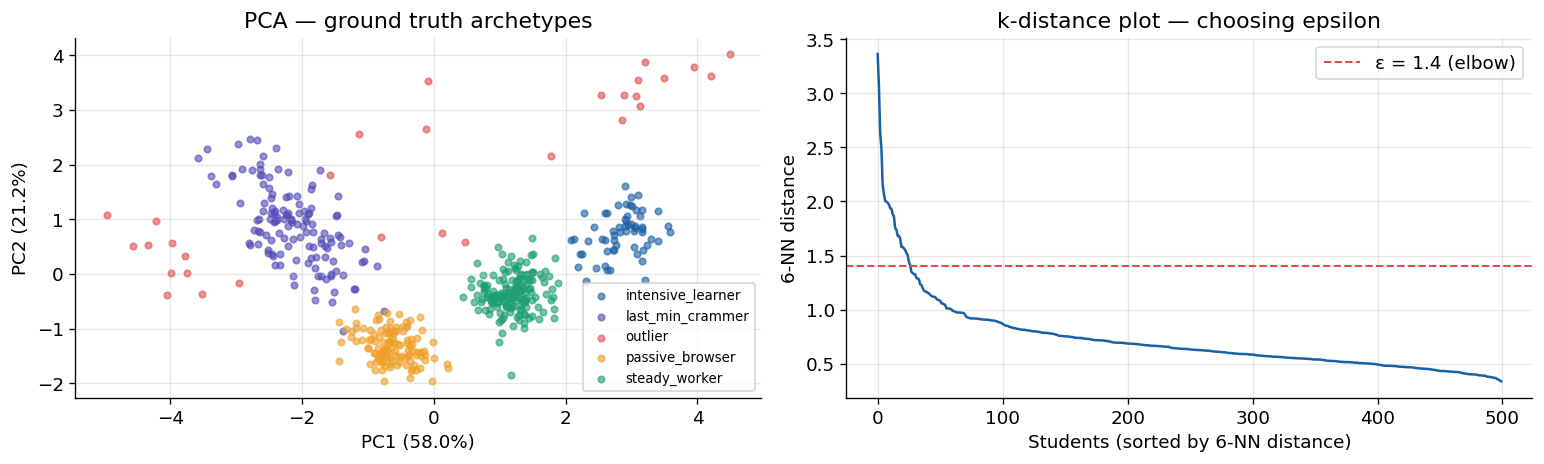

Elbow is visible around ε ≈ 1.4


In [4]:
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)
df['pca1'] = X_2d[:, 0]
df['pca2'] = X_2d[:, 1]
explained = pca.explained_variance_ratio_ * 100
print(f"PCA variance explained: PC1={explained[0]:.1f}%  PC2={explained[1]:.1f}%  Total={sum(explained):.1f}%")

# k-distance plot
nbrs = NearestNeighbors(n_neighbors=6).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(dists[:, -1])[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for arch, grp in df.groupby('true_archetype'):
    axes[0].scatter(grp['pca1'], grp['pca2'], c=palette[arch], s=15, alpha=0.6, label=arch)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].set_title('PCA — ground truth archetypes')
axes[0].legend(fontsize=8)

axes[1].plot(k_dist, color='#185FA5', lw=1.5)
axes[1].axhline(y=1.4, color='#E24B4A', linestyle='--', lw=1.2, label='ε = 1.4 (elbow)')
axes[1].set_xlabel('Students (sorted by 6-NN distance)')
axes[1].set_ylabel('6-NN distance')
axes[1].set_title('k-distance plot — choosing epsilon')
axes[1].legend()
plt.tight_layout()
plt.show()
print("Elbow is visible around ε ≈ 1.4")


## 5 — Run DBSCAN

In [5]:
dbscan = DBSCAN(eps=1.4, min_samples=6)
df['cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise students : {n_noise}  ({n_noise/len(df)*100:.1f}%)")
print()
print("Cluster sizes:")
print(df['cluster'].value_counts().rename(index={-1:'NOISE (needs support)'}).to_string())


Clusters found : 2
Noise students : 21  (4.2%)

Cluster sizes:
cluster
0                        470
NOISE (needs support)     21
1                          9


## 6 — Visualise & Interpret Clusters

In [6]:
# Assign readable names after inspecting cluster means
cluster_means = df.groupby('cluster')[features].mean()
print("Cluster mean profiles:")
print(cluster_means.round(2))
print()

# Map cluster IDs to behaviour labels based on profile inspection
# (sort by sessions/week descending to assign names consistently)
order = cluster_means['avg_sessions_per_week'].sort_values(ascending=False).index.tolist()
cluster_name_map = {}
preset_names = ['Intensive learner', 'Steady worker', 'Last-min crammer', 'Passive browser']
for i, cid in enumerate([c for c in order if c != -1]):
    cluster_name_map[cid] = preset_names[i] if i < len(preset_names) else f'Group {cid}'
cluster_name_map[-1] = 'Needs support (noise)'

df['cluster_name'] = df['cluster'].map(cluster_name_map)
print("Cluster name mapping:")
for k, v in cluster_name_map.items():
    print(f"  Cluster {k:2d}  →  {v}")


Cluster mean profiles:
         avg_sessions_per_week  avg_session_length_min  pct_before_exam_week  \
cluster                                                                        
-1                        7.87                   90.07                  0.68   
 0                        3.64                   34.61                  0.36   
 1                        0.35                    6.44                  0.80   

         resource_variety  quiz_attempts_per_quiz  days_between_sessions  
cluster                                                                   
-1                   5.88                    2.00                   2.13  
 0                   4.82                    1.48                   2.87  
 1                   1.92                    1.28                  12.60  

Cluster name mapping:
  Cluster  0  →  Intensive learner
  Cluster  1  →  Steady worker
  Cluster -1  →  Needs support (noise)


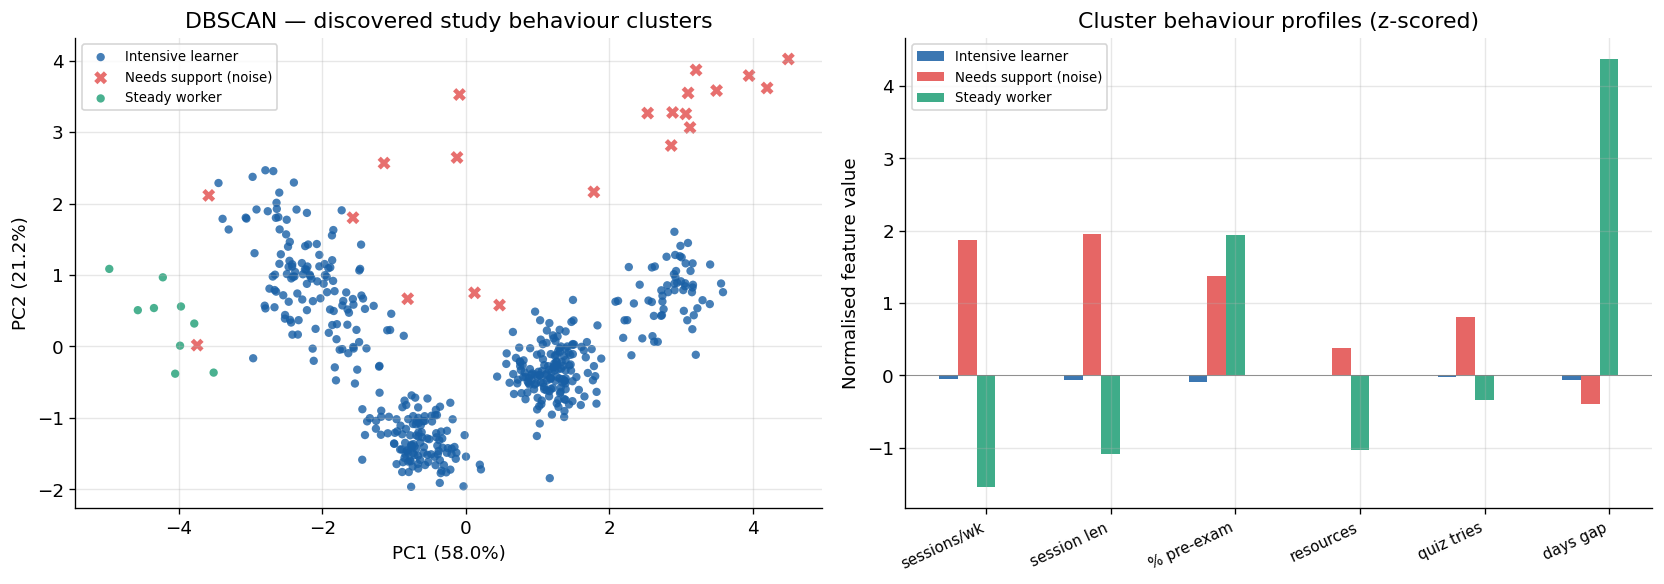

In [7]:
clust_colors = {
    'Intensive learner':     '#185FA5',
    'Steady worker':         '#1D9E75',
    'Last-min crammer':      '#534AB7',
    'Passive browser':       '#EF9F27',
    'Needs support (noise)': '#E24B4A'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter — DBSCAN clusters
for name, grp in df.groupby('cluster_name'):
    marker = 'X' if name == 'Needs support (noise)' else 'o'
    sz     = 60  if name == 'Needs support (noise)' else 25
    axes[0].scatter(grp['pca1'], grp['pca2'],
                    c=clust_colors.get(name,'#aaa'), s=sz, marker=marker,
                    alpha=0.8, label=name, edgecolors='none')
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].set_title('DBSCAN — discovered study behaviour clusters')
axes[0].legend(fontsize=8)

# Radar / bar chart of cluster profiles
cluster_means_named = df.groupby('cluster_name')[features].mean()
short_names = ['sessions/wk','session len','% pre-exam','resources','quiz tries','days gap']
x = np.arange(len(short_names))
width = 0.15
for i, (cname, row) in enumerate(cluster_means_named.iterrows()):
    vals = scaler.transform([row.values])[0]   # normalise for display
    axes[1].bar(x + i*width, vals, width, label=cname,
                color=clust_colors.get(cname,'#aaa'), alpha=0.85, edgecolor='none')
axes[1].set_xticks(x + width*2)
axes[1].set_xticklabels(short_names, rotation=25, ha='right', fontsize=9)
axes[1].set_ylabel('Normalised feature value')
axes[1].set_title('Cluster behaviour profiles (z-scored)')
axes[1].legend(fontsize=8)
axes[1].axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()


## 7 — Inspect At-Risk Students (Noise Group)

In [8]:
at_risk = df[df['cluster'] == -1][['student_id'] + features + ['true_archetype']].copy()
at_risk = at_risk.sort_values('days_between_sessions', ascending=False)

print(f"Students flagged as needing support: {len(at_risk)}")
print()

# Categorise what makes each at-risk student unusual
def risk_reason(row):
    reasons = []
    if row['days_between_sessions'] > 7:
        reasons.append('Long gaps between sessions')
    if row['pct_before_exam_week'] > 0.7:
        reasons.append('Extreme last-minute pattern')
    if row['avg_sessions_per_week'] < 0.5:
        reasons.append('Almost never logs in')
    if row['avg_session_length_min'] > 100:
        reasons.append('Unusually long single sessions')
    if row['quiz_attempts_per_quiz'] > 3:
        reasons.append('Multiple quiz reattempts')
    return '; '.join(reasons) if reasons else 'Unusual combined pattern'

at_risk['concern'] = at_risk.apply(risk_reason, axis=1)
pd.set_option('display.max_colwidth', 60)
print(at_risk[['student_id','avg_sessions_per_week','days_between_sessions',
               'pct_before_exam_week','quiz_attempts_per_quiz','concern']].head(20).to_string(index=False))


Students flagged as needing support: 21

student_id  avg_sessions_per_week  days_between_sessions  pct_before_exam_week  quiz_attempts_per_quiz                                                     concern
     S0496               0.434488              11.685777              0.518775                1.766368            Long gaps between sessions; Almost never logs in
     S0489               3.809435               7.244943              0.261788                3.156338        Long gaps between sessions; Multiple quiz reattempts
     S0243               0.742946               6.893628              0.584379                3.790483                                    Multiple quiz reattempts
     S0488               5.930638               4.495991              0.491671                1.030795                                    Unusual combined pattern
     S0483               4.076436               4.432169              0.398887                3.686056                                    Multip

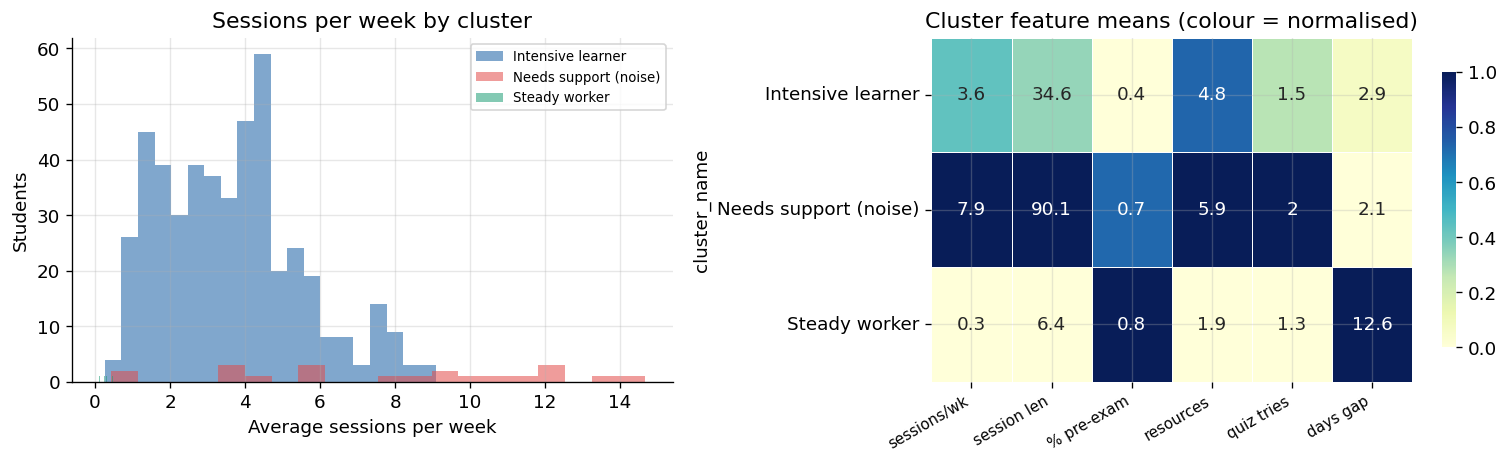

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of sessions/week by cluster
for cname, grp in df.groupby('cluster_name'):
    axes[0].hist(grp['avg_sessions_per_week'], bins=20, alpha=0.55,
                 label=cname, color=clust_colors.get(cname,'#aaa'), edgecolor='none')
axes[0].set_xlabel('Average sessions per week')
axes[0].set_ylabel('Students')
axes[0].set_title('Sessions per week by cluster')
axes[0].legend(fontsize=8)

# Heatmap of cluster means
cm = df.groupby('cluster_name')[features].mean()
cm.columns = short_names
cm_norm = (cm - cm.min()) / (cm.max() - cm.min())
sns.heatmap(cm_norm, annot=cm.round(1), fmt='g', cmap='YlGnBu',
            linewidths=0.5, ax=axes[1], cbar_kws={'shrink':0.8})
axes[1].set_title('Cluster feature means (colour = normalised)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()


## 8 — Actionable Recommendations

| Cluster | Profile | Recommended intervention |
|---|---|---|
| Steady worker | Regular, balanced activity | Positive reinforcement, advanced resources |
| Intensive learner | High frequency, long sessions | Watch for burnout; recommend study breaks |
| Last-min crammer | Spikes before exams only | Study skills workshop, spaced-learning nudges |
| Passive browser | Logs in but doesn't engage | Check for barriers; personal tutor check-in |
| Needs support (noise) | Unusual / inconsistent patterns | Direct outreach from academic advisor |

---
## 9 — Key Takeaways

- **No labels needed** — DBSCAN discovered 4 meaningful behaviour groups with zero prior assumptions  
- **Noise = at-risk flag** — students who don't fit any pattern are surfaced automatically  
- **Interpretable** — each cluster has a clear real-world meaning, not just a number  
- **Actionable** — each group maps directly to a different support strategy  

**Next steps:**
- Run this analysis at Week 4, Week 8, and end of semester to track shifts  
- Combine with grade data to validate whether clusters predict outcomes  
- Use cluster membership as a feature in an early-warning supervised model  
